In [3]:
import torch
import torch.nn.functional as F


In [4]:
from audio_classification_playground.vox_profile.emotion.wavlm_emotion_dim import WavLMWrapper
from audio_classification_playground.vox_profile.emotion.whisper_emotion_dim import WhisperWrapper

In [6]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

model = WhisperWrapper.from_pretrained("tiantiaf/whisper-large-v3-msp-podcast-emotion-dim").to(device)
model = model.eval()

Some weights of WhisperModel were not initialized from the model checkpoint at openai/whisper-large-v3 and are newly initialized because the shapes did not match:
- encoder.embed_positions.weight: found shape torch.Size([1500, 1280]) in the checkpoint and torch.Size([750, 1280]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
# Load model from Huggingface
model = WavLMWrapper.from_pretrained("tiantiaf/wavlm-large-msp-podcast-emotion-dim").to(device)
model = model.eval()

In [7]:
import librosa
import torch
import torch.nn.functional as F
SR = 16_000
WINDOW_SEC = 3.5
HOP_SEC = 0.25
BATCH_SIZE = 128
window_samples = int(WINDOW_SEC * SR)   # 56,000
hop_samples = int(HOP_SEC * SR)         # 16,000

In [36]:
audio_path = "/workspace/tmp_data/robbiestaniforth-2026-2-9__14-44-54.mp3"
audio,_ = librosa.load(audio_path, sr=SR, mono=True)

In [37]:
audio.shape[0]/SR/60

74.51740625000001

In [38]:
len(windows)

14157

In [39]:
# 2. Convert to tensor
audio_t = torch.from_numpy(audio).float()
# 3. Pad so the last partial window isn't silently dropped
remainder = (len(audio_t) - window_samples) % hop_samples
if remainder != 0:
    pad_needed = hop_samples - remainder
    audio_t = F.pad(audio_t, (0, pad_needed))
# 4. Unfold into overlapping windows  →  [N, window_samples]
#    unfold(dim, size, step) returns a view — no copy
windows = audio_t.unfold(0, window_samples, hop_samples)
# 5. Batch inference
all_arousal, all_valence, all_dominance = [], [], []
for i in range(0, len(windows), BATCH_SIZE):
    batch = windows[i : i + BATCH_SIZE].to(device)
    with torch.no_grad():
        a, v, d = model(batch)
    all_arousal.append(a.cpu())
    all_valence.append(v.cpu())
    all_dominance.append(d.cpu())
arousal   = torch.cat(all_arousal).squeeze(-1).numpy()    # [N]
valence   = torch.cat(all_valence).squeeze(-1).numpy()
dominance = torch.cat(all_dominance).squeeze(-1).numpy()


In [40]:
# pod_arousal = arousal
# pod_valence = valence
# pod_dominance = dominance


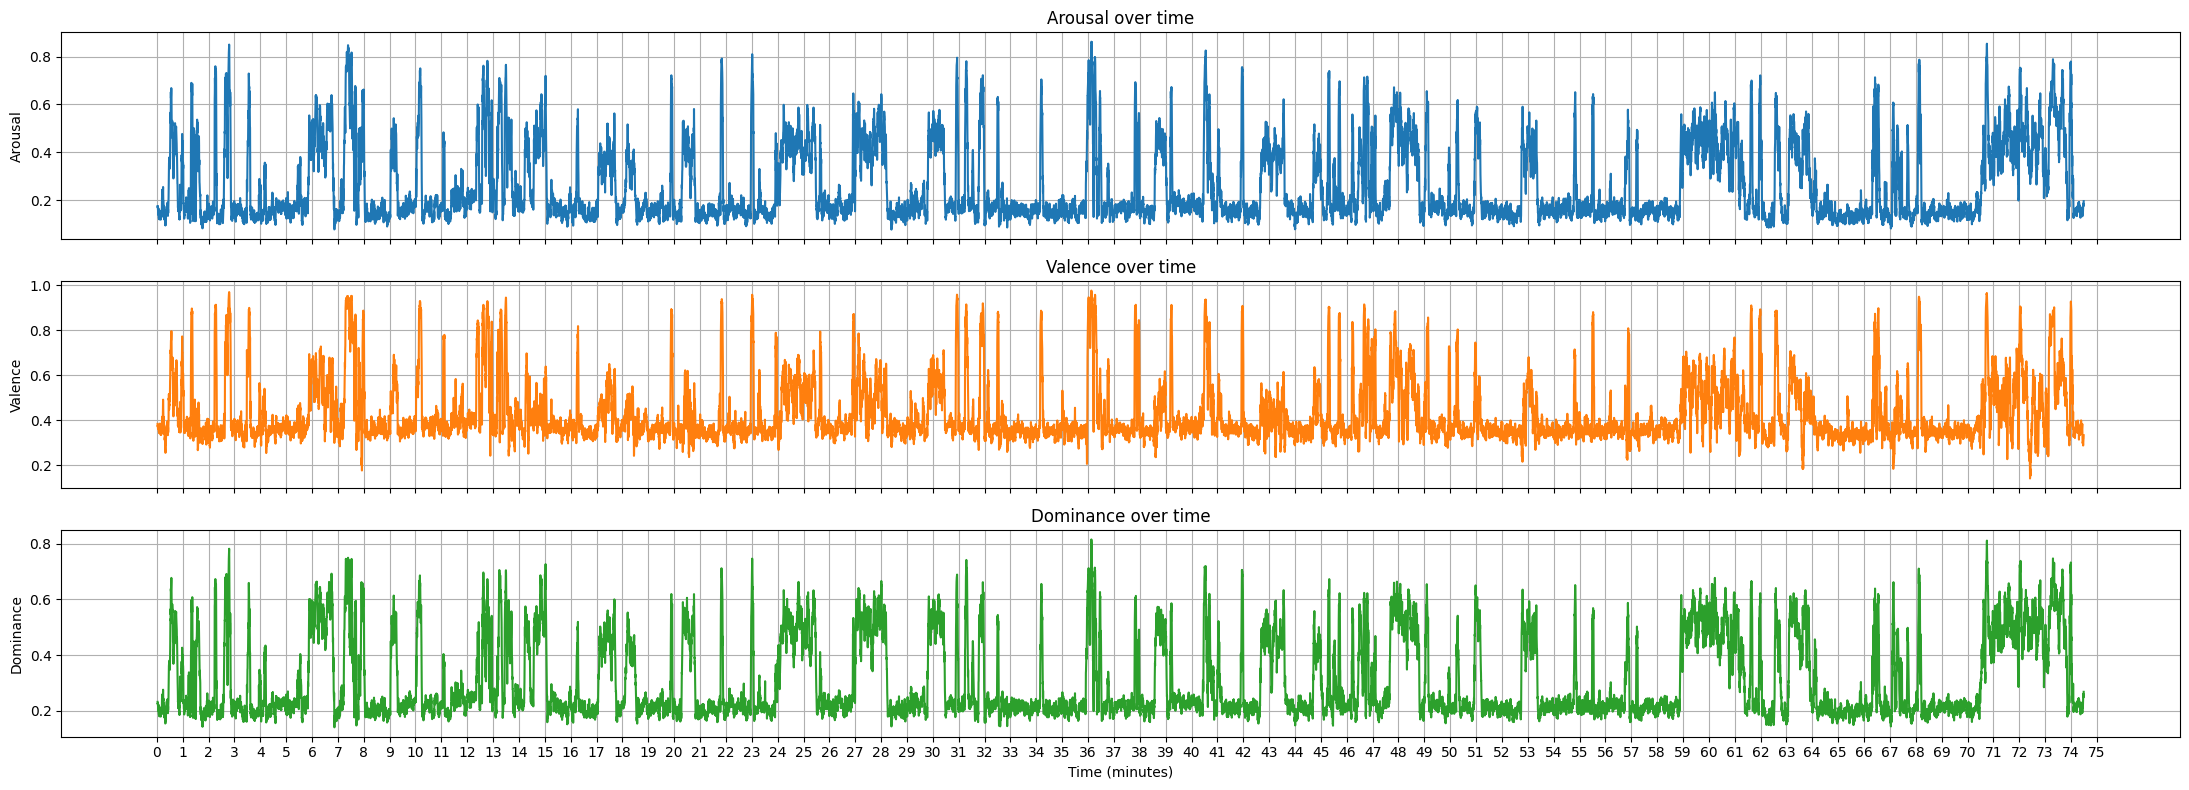

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Compute time axis for center of each window, in seconds first
num_windows = len(arousal)
window_centers_sec = np.arange(num_windows) * HOP_SEC + WINDOW_SEC / 2
window_centers_min = window_centers_sec / 60.0

fig, axs = plt.subplots(3, 1, figsize=(22, 8), sharex=True)  # Widens the figure more

# Set major ticks at every minute (floor to closest integer min, up to last min)
time_min_max = window_centers_min[-1]
minute_ticks = np.arange(0, time_min_max + 1, 1)
axs[-1].set_xticks(minute_ticks)

axs[0].plot(window_centers_min, arousal, label="Arousal", color="tab:blue")
axs[0].set_ylabel("Arousal")
axs[0].set_title("Arousal over time")
axs[0].grid(True)
axs[0].set_xticks(minute_ticks)
axs[0].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

axs[1].plot(window_centers_min, valence, label="Valence", color="tab:orange")
axs[1].set_ylabel("Valence")
axs[1].set_title("Valence over time")
axs[1].grid(True)
axs[1].set_xticks(minute_ticks)
axs[1].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

axs[2].plot(window_centers_min, dominance, label="Dominance", color="tab:green")
axs[2].set_xlabel("Time (minutes)")
axs[2].set_ylabel("Dominance")
axs[2].set_title("Dominance over time")
axs[2].grid(True)
axs[2].set_xticks(minute_ticks)
axs[2].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

# Format the x-axis as integer minutes
axs[2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

plt.tight_layout()
plt.show()

In [51]:
VAD_CONFIG["min_speech_sec"]

1.0

Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /workspace/.cache/torch/hub/master.zip
Total frames:    17872  (74.5 min)
Speech frames:   4719  (19.7 min,  26.4%)
Silence frames:  13153  (54.8 min)
Speech blocks:   60

Block duration stats:
  min:    1.8s
  median: 5.2s
  mean:   19.7s
  max:    147.5s
  >10s:   25


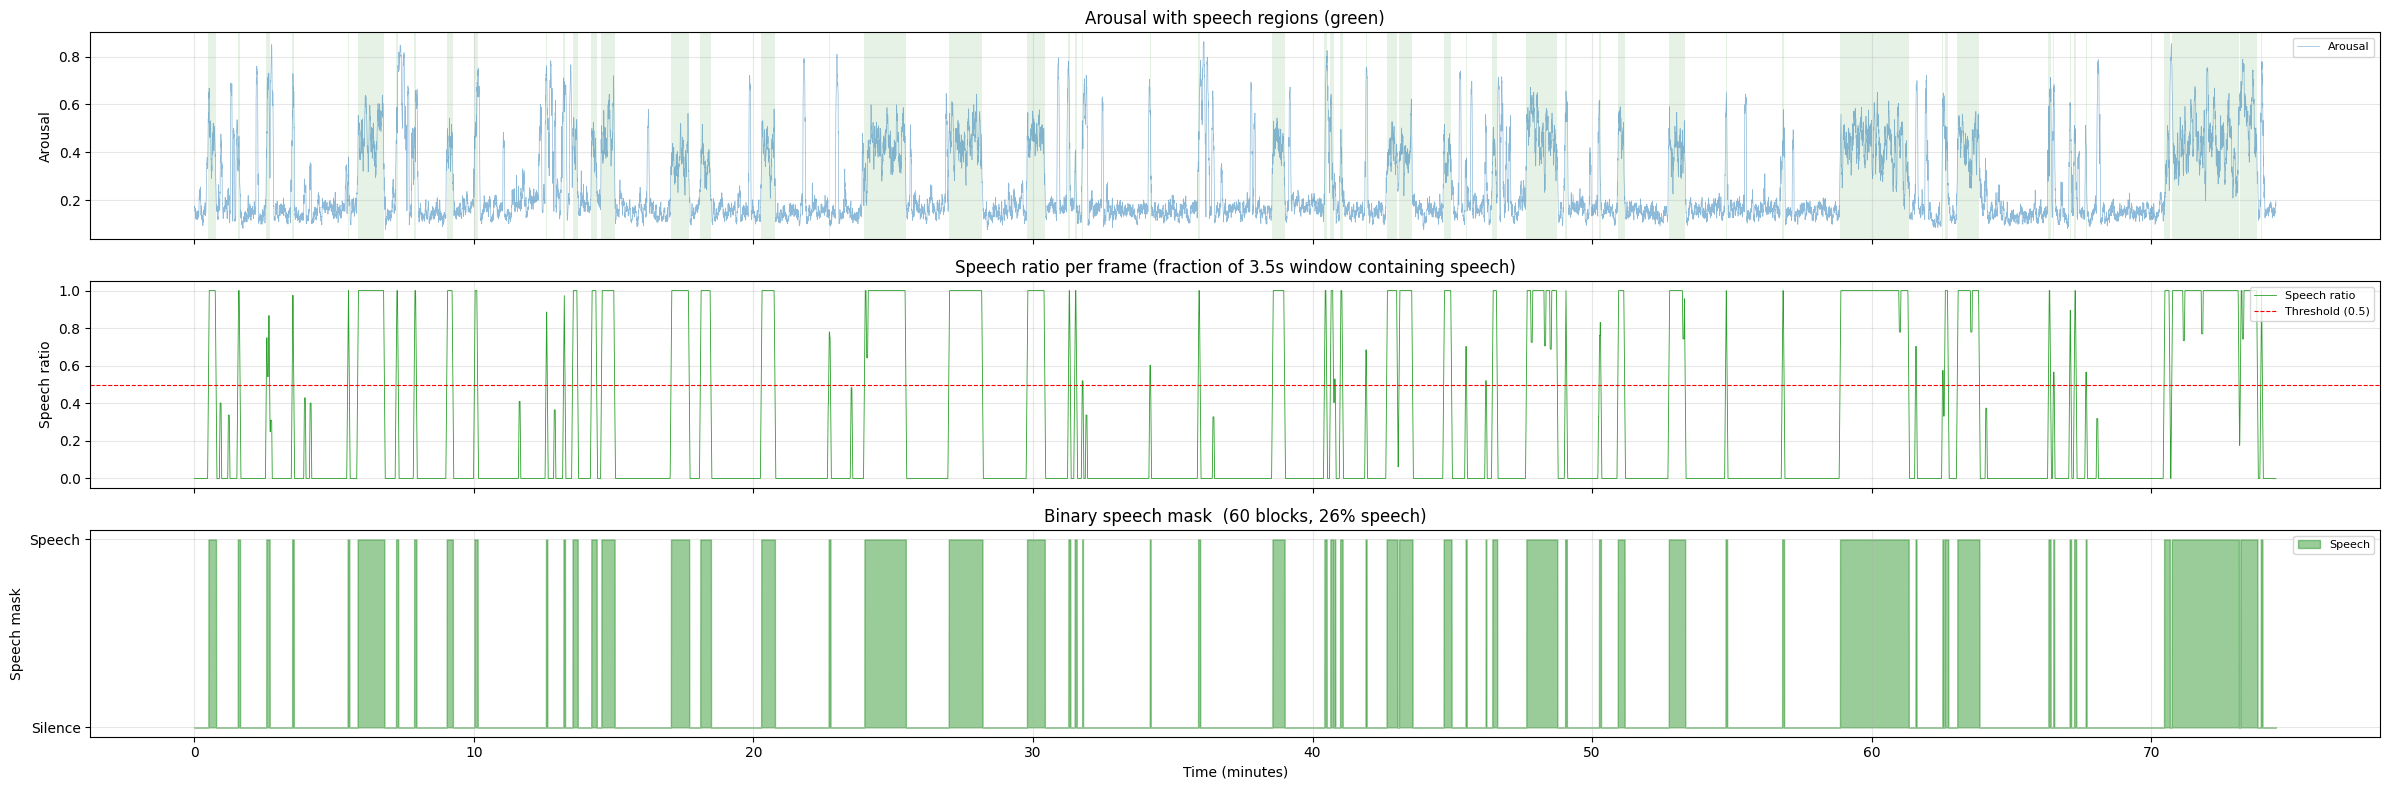

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── VAD Configuration ────────────────────────────────────────────────────────
VAD_CONFIG = {
    "speech_threshold": 0.5,         # Silero probability threshold
    "min_speech_sec": 0.1,           # discard speech blocks shorter than this
    "min_silence_sec": 0.75,         # bridge silence gaps shorter than this (keeps utterances whole)
    "speech_ratio_threshold": 0.5,   # fraction of 3.5s window that must be speech
}

# ── Load Silero VAD ──────────────────────────────────────────────────────────
vad_model, vad_utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False,
    trust_repo=True,
)
(get_speech_timestamps, _, read_audio, _, _) = vad_utils

# ── Run VAD at native resolution ─────────────────────────────────────────────
# Silero VAD expects 16kHz mono float32 tensor
audio_tensor = torch.from_numpy(audio).float()

speech_timestamps = get_speech_timestamps(
    audio_tensor,
    vad_model,
    sampling_rate=SR,
    threshold=VAD_CONFIG["speech_threshold"],
    min_speech_duration_ms=int(VAD_CONFIG["min_speech_sec"] * 1000),
    min_silence_duration_ms=int(VAD_CONFIG["min_silence_sec"] * 1000),
    return_seconds=False,
)

# ── Build sample-level speech mask ───────────────────────────────────────────
speech_mask_samples = np.zeros(len(audio), dtype=bool)
for ts in speech_timestamps:
    speech_mask_samples[ts['start']:ts['end']] = True

# ── Align to prediction frame grid ──────────────────────────────────────────
# Each prediction frame t covers a window: [t * hop_samples, t * hop_samples + window_samples)
# Compute speech ratio for each window
n_frames = len(arousal)
hop_samples = int(HOP_SEC * SR)
window_samples = int(WINDOW_SEC * SR)

speech_ratio = np.zeros(n_frames, dtype=np.float32)
for t in range(n_frames):
    win_start = t * hop_samples
    win_end = min(win_start + window_samples, len(speech_mask_samples))
    if win_end > win_start:
        speech_ratio[t] = speech_mask_samples[win_start:win_end].mean()

# Binary mask: frame is "speech" if enough of its window contains speech
speech_mask = speech_ratio >= VAD_CONFIG["speech_ratio_threshold"]

# ── Build speech block list ──────────────────────────────────────────────────
def mask_to_blocks(mask):
    """Convert boolean mask to list of (start_frame, end_frame) tuples."""
    blocks = []
    in_block = False
    for t in range(len(mask)):
        if mask[t] and not in_block:
            start = t
            in_block = True
        elif not mask[t] and in_block:
            blocks.append((start, t - 1))
            in_block = False
    if in_block:
        blocks.append((start, len(mask) - 1))
    return blocks

speech_blocks = mask_to_blocks(speech_mask)

# ── Summary ──────────────────────────────────────────────────────────────────
total_frames = len(arousal)
speech_frames = speech_mask.sum()
speech_pct = 100.0 * speech_frames / total_frames
total_dur = total_frames * HOP_SEC
speech_dur = speech_frames * HOP_SEC

print(f"Total frames:    {total_frames}  ({total_dur / 60:.1f} min)")
print(f"Speech frames:   {speech_frames}  ({speech_dur / 60:.1f} min,  {speech_pct:.1f}%)")
print(f"Silence frames:  {total_frames - speech_frames}  ({(total_dur - speech_dur) / 60:.1f} min)")
print(f"Speech blocks:   {len(speech_blocks)}")
print()

block_durations = [(e - s + 1) * HOP_SEC for s, e in speech_blocks]
print(f"Block duration stats:")
print(f"  min:    {min(block_durations):.1f}s")
print(f"  median: {np.median(block_durations):.1f}s")
print(f"  mean:   {np.mean(block_durations):.1f}s")
print(f"  max:    {max(block_durations):.1f}s")
print(f"  >10s:   {sum(1 for d in block_durations if d > 10)}")

# ── Visualization ────────────────────────────────────────────────────────────
time_min = np.arange(n_frames) * HOP_SEC / 60.0

fig, axs = plt.subplots(3, 1, figsize=(24, 8), sharex=True)

# Panel 1: raw arousal with speech mask overlay
ax = axs[0]
ax.plot(time_min, arousal, alpha=0.5, linewidth=0.5, color="tab:blue", label="Arousal")
for s, e in speech_blocks:
    ax.axvspan(time_min[s], time_min[e], alpha=0.1, color="green", linewidth=0)
ax.set_ylabel("Arousal")
ax.set_title("Arousal with speech regions (green)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: speech ratio per frame
ax = axs[1]
ax.plot(time_min, speech_ratio, linewidth=0.6, color="tab:green", label="Speech ratio")
ax.axhline(VAD_CONFIG["speech_ratio_threshold"], color="red", linestyle="--",
           linewidth=0.8, label=f"Threshold ({VAD_CONFIG['speech_ratio_threshold']})")
ax.set_ylabel("Speech ratio")
ax.set_title("Speech ratio per frame (fraction of 3.5s window containing speech)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: speech mask (binary)
ax = axs[2]
ax.fill_between(time_min, 0, speech_mask.astype(float), alpha=0.4, color="green", label="Speech")
ax.set_ylabel("Speech mask")
ax.set_title(f"Binary speech mask  ({len(speech_blocks)} blocks, {speech_pct:.0f}% speech)")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Silence", "Speech"])
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Time (minutes)")

plt.tight_layout()
plt.show()

In [42]:
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation

signals = {"Arousal": arousal, "Valence": valence, "Dominance": dominance}

# ── 1. Global descriptive stats ──────────────────────────────────────────────
print("=" * 70)
print("1. GLOBAL DESCRIPTIVE STATISTICS")
print("=" * 70)
rows = []
for name, sig in signals.items():
    mad = median_abs_deviation(sig, scale=1.0)
    rows.append({
        "Signal": name,
        "Mean": f"{sig.mean():.4f}",
        "Median": f"{np.median(sig):.4f}",
        "Std": f"{sig.std():.4f}",
        "MAD": f"{mad:.4f}",
        "MAD/Std": f"{mad / sig.std():.3f}",
        "Min": f"{sig.min():.4f}",
        "Max": f"{sig.max():.4f}",
        "N_frames": len(sig),
    })
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nHOP_SEC = {HOP_SEC}  →  total duration ≈ {len(arousal) * HOP_SEC / 60:.1f} min")
print("(MAD/Std ≈ 0.675 for Gaussian; lower means heavy tails / outliers)\n")

# ── 2. Autocorrelation at short lags ─────────────────────────────────────────
print("=" * 70)
print("2. AUTOCORRELATION AT SHORT LAGS")
print("=" * 70)
lags = [1, 2, 4, 8, 16, 32]
acf_rows = []
for name, sig in signals.items():
    sig_centered = sig - sig.mean()
    var = np.var(sig_centered)
    acf_vals = {}
    for lag in lags:
        if lag < len(sig):
            acf = np.mean(sig_centered[:-lag] * sig_centered[lag:]) / var
            acf_vals[f"lag {lag} ({lag * HOP_SEC:.2f}s)"] = f"{acf:.4f}"
        else:
            acf_vals[f"lag {lag} ({lag * HOP_SEC:.2f}s)"] = "N/A"
    acf_rows.append({"Signal": name, **acf_vals})
print(pd.DataFrame(acf_rows).to_string(index=False))
print()

# ── 3. Stationarity: per-chunk statistics ────────────────────────────────────
print("=" * 70)
print("3. STATIONARITY CHECK (per-chunk mean / std)")
print("=" * 70)
n_chunks = 6
chunk_size = len(arousal) // n_chunks
for name, sig in signals.items():
    print(f"\n  {name}:")
    print(f"  {'Chunk':<12} {'Time span':<20} {'Mean':>8} {'Std':>8} {'Median':>8}")
    print(f"  {'-'*60}")
    for i in range(n_chunks):
        start_idx = i * chunk_size
        end_idx = (i + 1) * chunk_size if i < n_chunks - 1 else len(sig)
        chunk = sig[start_idx:end_idx]
        t0 = start_idx * HOP_SEC / 60
        t1 = end_idx * HOP_SEC / 60
        print(f"  {i+1:<12} {t0:>5.1f}–{t1:>5.1f} min     {chunk.mean():>8.4f} {chunk.std():>8.4f} {np.median(chunk):>8.4f}")

print()

# ── 4. Rolling MAD distribution (baseline window = 45s) ─────────────────────
print("=" * 70)
print("4. ROLLING MAD DISTRIBUTION (45s window)")
print("=" * 70)
baseline_window = int(45.0 / HOP_SEC)
print(f"   baseline window = {baseline_window} frames = {baseline_window * HOP_SEC:.0f}s\n")

for name, sig in signals.items():
    s = pd.Series(sig)
    rolling_med = s.rolling(baseline_window, center=True, min_periods=baseline_window // 2).median()
    rolling_mad = (s - rolling_med).abs().rolling(baseline_window, center=True, min_periods=baseline_window // 2).median()
    mad_vals = rolling_mad.dropna().values
    print(f"  {name}:")
    print(f"    Rolling MAD  —  median: {np.median(mad_vals):.4f},  "
          f"min: {mad_vals.min():.4f},  max: {mad_vals.max():.4f},  "
          f"std: {mad_vals.std():.4f},  CoV: {mad_vals.std() / np.median(mad_vals):.3f}")
print("\n(CoV = coefficient of variation of the MAD; >0.3 means noise floor varies a lot)\n")

# ── 5. Cross-correlation between signals ─────────────────────────────────────
print("=" * 70)
print("5. PAIRWISE PEARSON CORRELATION")
print("=" * 70)
pairs = [("Arousal", "Valence"), ("Arousal", "Dominance"), ("Valence", "Dominance")]
for n1, n2 in pairs:
    r = np.corrcoef(signals[n1], signals[n2])[0, 1]
    print(f"  {n1:>10} ↔ {n2:<10}  r = {r:+.4f}")
print()

1. GLOBAL DESCRIPTIVE STATISTICS
   Signal   Mean Median    Std    MAD MAD/Std    Min    Max  N_frames
  Arousal 0.2642 0.1790 0.1630 0.0471   0.289 0.0783 0.8617     17872
  Valence 0.4305 0.3720 0.1417 0.0370   0.261 0.1415 0.9764     17872
Dominance 0.3116 0.2305 0.1464 0.0380   0.260 0.1414 0.8153     17872

HOP_SEC = 0.25  →  total duration ≈ 74.5 min
(MAD/Std ≈ 0.675 for Gaussian; lower means heavy tails / outliers)

2. AUTOCORRELATION AT SHORT LAGS
   Signal lag 1 (0.25s) lag 2 (0.50s) lag 4 (1.00s) lag 8 (2.00s) lag 16 (4.00s) lag 32 (8.00s)
  Arousal        0.9813        0.9606        0.9062        0.7782         0.5411         0.4015
  Valence        0.9700        0.9370        0.8545        0.6721         0.3621         0.2416
Dominance        0.9849        0.9686        0.9258        0.8240         0.6277         0.4969

3. STATIONARITY CHECK (per-chunk mean / std)

  Arousal:
  Chunk        Time span                Mean      Std   Median
  ---------------------------------

In [43]:
# ── Event Detection Configuration ────────────────────────────────────────────
EVENT_CONFIG = {
    # Pre-smoothing (applied to raw signal before baseline estimation)
    "pre_smooth_frames": 3,          # median filter width in frames (0.75s)

    # Baseline estimation
    "baseline_window_frames": 180,   # rolling median window (45s)

    # Local noise scale
    "mad_window_frames": 180,        # rolling MAD window (45s)
    "mad_scale_factor": 1.4826,      # MAD → σ conversion (exact for Gaussian)
    "mad_eps": 1e-6,                 # numerical stability floor

    # Z-score smoothing (applied after normalization)
    "zscore_smooth_frames": 7,       # median filter width (1.75s)

    # Hysteresis thresholds
    "enter_threshold": 2.0,          # z-score to start an event
    "exit_threshold": 0.75,          # z-score to end an event

    # Temporal constraints
    "min_event_duration_sec": 2.0,   # discard events shorter than this
    "min_gap_merge_sec": 1.0,        # merge events closer than this

    # Fusion
    "activation_weights": {"Arousal": 0.5, "Dominance": 0.5},  # A≈D, so average them
}

In [44]:
import numpy as np
import pandas as pd
from scipy.ndimage import median_filter

def compute_robust_zscore(sig, cfg):
    """Raw signal → pre-smooth → baseline → MAD → z-score → smooth z-score."""
    s = pd.Series(sig)
    
    smoothed = median_filter(sig, size=cfg["pre_smooth_frames"])
    s_smooth = pd.Series(smoothed)

    baseline = s_smooth.rolling(
        cfg["baseline_window_frames"], center=True,
        min_periods=cfg["baseline_window_frames"] // 2
    ).median()

    deviation = s_smooth - baseline

    rolling_mad = deviation.abs().rolling(
        cfg["mad_window_frames"], center=True,
        min_periods=cfg["mad_window_frames"] // 2
    ).median()

    z = deviation / (cfg["mad_scale_factor"] * rolling_mad + cfg["mad_eps"])

    z_smooth = pd.Series(median_filter(z.values, size=cfg["zscore_smooth_frames"]))
    z_smooth.index = z.index

    return z_smooth, baseline, rolling_mad


def detect_events_hysteresis(z, cfg, hop_sec, direction="positive"):
    """Detect events using Schmitt-trigger hysteresis on a z-score series."""
    enter_thr = cfg["enter_threshold"]
    exit_thr = cfg["exit_threshold"]
    min_dur_frames = int(cfg["min_event_duration_sec"] / hop_sec)
    min_gap_frames = int(cfg["min_gap_merge_sec"] / hop_sec)

    if direction == "negative":
        z = -z

    vals = z.values
    events = []
    in_event = False
    start = 0

    for t in range(len(vals)):
        if np.isnan(vals[t]):
            if in_event:
                events.append((start, t - 1))
                in_event = False
            continue
        if not in_event and vals[t] > enter_thr:
            start = t
            in_event = True
        elif in_event and vals[t] < exit_thr:
            events.append((start, t))
            in_event = False

    if in_event:
        events.append((start, len(vals) - 1))

    # Duration filter
    events = [(s, e) for s, e in events if (e - s) >= min_dur_frames]

    # Merge close events
    if len(events) > 1:
        merged = [events[0]]
        for s, e in events[1:]:
            prev_s, prev_e = merged[-1]
            if s - prev_e <= min_gap_frames:
                merged[-1] = (prev_s, e)
            else:
                merged.append((s, e))
        events = merged

    # Duration filter again after merging
    events = [(s, e) for s, e in events if (e - s) >= min_dur_frames]

    return events


def events_to_dataframe(events, z, hop_sec, signal_name, direction):
    """Convert event list to a descriptive DataFrame."""
    rows = []
    vals = z.values
    for s, e in events:
        segment = vals[s:e+1]
        peak_val = np.nanmax(segment) if direction == "positive" else np.nanmin(segment)
        peak_idx = s + (np.nanargmax(segment) if direction == "positive" else np.nanargmin(segment))
        rows.append({
            "signal": signal_name,
            "direction": direction,
            "start_sec": s * hop_sec,
            "end_sec": e * hop_sec,
            "duration_sec": (e - s) * hop_sec,
            "peak_sec": peak_idx * hop_sec,
            "peak_z": peak_val,
            "mean_z": np.nanmean(segment) if direction == "positive" else -np.nanmean(segment),
            "start_frame": s,
            "end_frame": e,
        })
    return pd.DataFrame(rows)


# ── Run the pipeline ─────────────────────────────────────────────────────────
cfg = EVENT_CONFIG
signals = {"Arousal": arousal, "Valence": valence, "Dominance": dominance}

z_scores = {}
baselines = {}
rolling_mads = {}
all_events_df = []

for name, sig in signals.items():
    z, bl, rmad = compute_robust_zscore(sig, cfg)
    z_scores[name] = z
    baselines[name] = bl
    rolling_mads[name] = rmad

    for direction in ["positive", "negative"]:
        events = detect_events_hysteresis(z, cfg, HOP_SEC, direction=direction)
        if events:
            df = events_to_dataframe(events, z, HOP_SEC, name, direction)
            all_events_df.append(df)

events_df = pd.concat(all_events_df, ignore_index=True) if all_events_df else pd.DataFrame()

# ── Activation axis (fused Arousal + Dominance) ──────────────────────────────
w = cfg["activation_weights"]
z_activation = sum(z_scores[k] * v for k, v in w.items())
z_scores["Activation"] = z_activation

for direction in ["positive", "negative"]:
    events = detect_events_hysteresis(z_activation, cfg, HOP_SEC, direction=direction)
    if events:
        df = events_to_dataframe(events, z_activation, HOP_SEC, "Activation", direction)
        all_events_df.append(df)

events_df = pd.concat(all_events_df, ignore_index=True) if all_events_df else pd.DataFrame()
events_df = events_df.sort_values("start_sec").reset_index(drop=True)

# ── Summary ──────────────────────────────────────────────────────────────────
print(f"Total events detected: {len(events_df)}")
print()
for (sig, dirn), group in events_df.groupby(["signal", "direction"]):
    print(f"  {sig:>12} {dirn:>8}: {len(group):>3} events,  "
          f"median duration = {group['duration_sec'].median():.1f}s,  "
          f"median |peak_z| = {group['peak_z'].abs().median():.2f}")

print("\n── Top 15 events by |peak_z| ──")
print(events_df.nlargest(15, "peak_z")[
    ["signal", "direction", "start_sec", "end_sec", "duration_sec", "peak_z"]
].to_string(index=False))

Total events detected: 489

    Activation negative:  26 events,  median duration = 3.5s,  median |peak_z| = 2.24
    Activation positive:  93 events,  median duration = 4.5s,  median |peak_z| = 4.76
       Arousal negative:  19 events,  median duration = 3.5s,  median |peak_z| = 2.31
       Arousal positive:  94 events,  median duration = 4.8s,  median |peak_z| = 5.03
     Dominance negative:  28 events,  median duration = 3.5s,  median |peak_z| = 2.43
     Dominance positive:  94 events,  median duration = 4.4s,  median |peak_z| = 4.53
       Valence negative:  33 events,  median duration = 2.8s,  median |peak_z| = 2.38
       Valence positive: 102 events,  median duration = 4.8s,  median |peak_z| = 4.88

── Top 15 events by |peak_z| ──
    signal direction  start_sec  end_sec  duration_sec    peak_z
   Valence  positive    2047.00  2055.25          8.25 28.338840
   Arousal  positive    2047.25  2054.75          7.50 26.347827
Activation  positive    2047.25  2054.50          7.25 2

In [45]:
z_smoothed, baseline, rolling_mad = compute_robust_zscore(arousal, cfg)

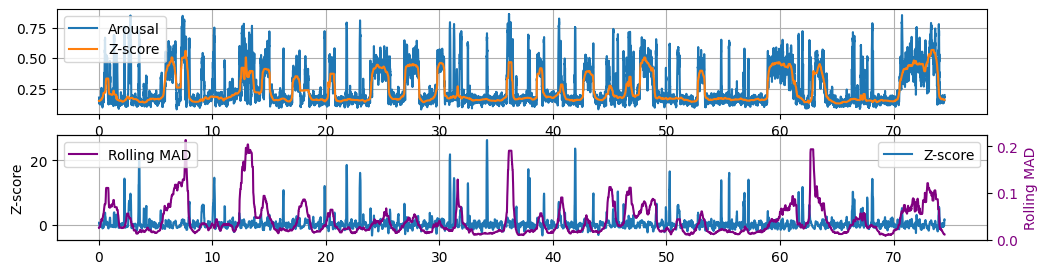

In [47]:
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=2,ncols=1,figsize=(12,3))
ax = axes[0]
ax.plot(window_centers_min,arousal,label="Arousal")
ax.plot(window_centers_min,baseline,label="Z-score")
ax.legend()
ax.grid(True)
ax = axes[1]
ax.plot(window_centers_min,z_smoothed,label="Z-score")
ax2 = ax.twinx()
ax2.plot(window_centers_min, rolling_mad, color="purple", label="Rolling MAD")
ax2.set_ylabel("Rolling MAD", color="purple")
ax2.tick_params(axis="y", labelcolor="purple")
ax2.legend(loc="upper left")
ax.legend()
ax.grid(True)
ax.set_ylabel("Z-score")
plt.show()


In [48]:
z_smoothed, baseline, rolling_mad = compute_robust_zscore(valence, cfg)

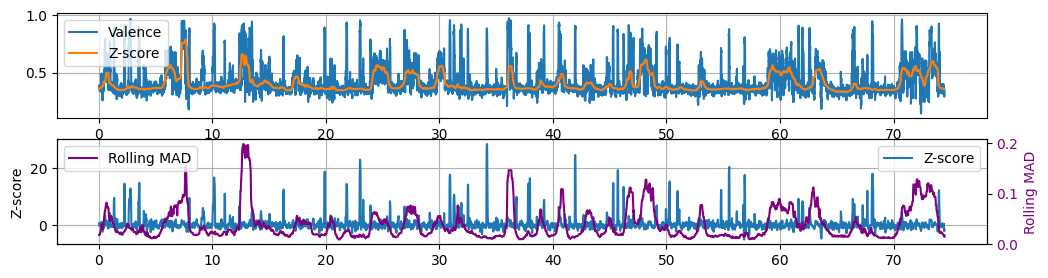

In [49]:
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=2,ncols=1,figsize=(12,3))
ax = axes[0]
ax.plot(window_centers_min,valence,label="Valence")
ax.plot(window_centers_min,baseline,label="Z-score")
ax.legend()
ax.grid(True)
ax = axes[1]
ax.plot(window_centers_min,z_smoothed,label="Z-score")
ax2 = ax.twinx()
ax2.plot(window_centers_min, rolling_mad, color="purple", label="Rolling MAD")
ax2.set_ylabel("Rolling MAD", color="purple")
ax2.tick_params(axis="y", labelcolor="purple")
ax2.legend(loc="upper left")
ax.legend()
ax.grid(True)
ax.set_ylabel("Z-score")
plt.show()


In [46]:
rolling_mad

0        0.025378
1        0.025407
2        0.026006
3        0.025723
4        0.026164
           ...   
17867    0.011478
17868    0.011377
17869    0.011276
17870    0.011257
17871    0.011238
Length: 17872, dtype: float64

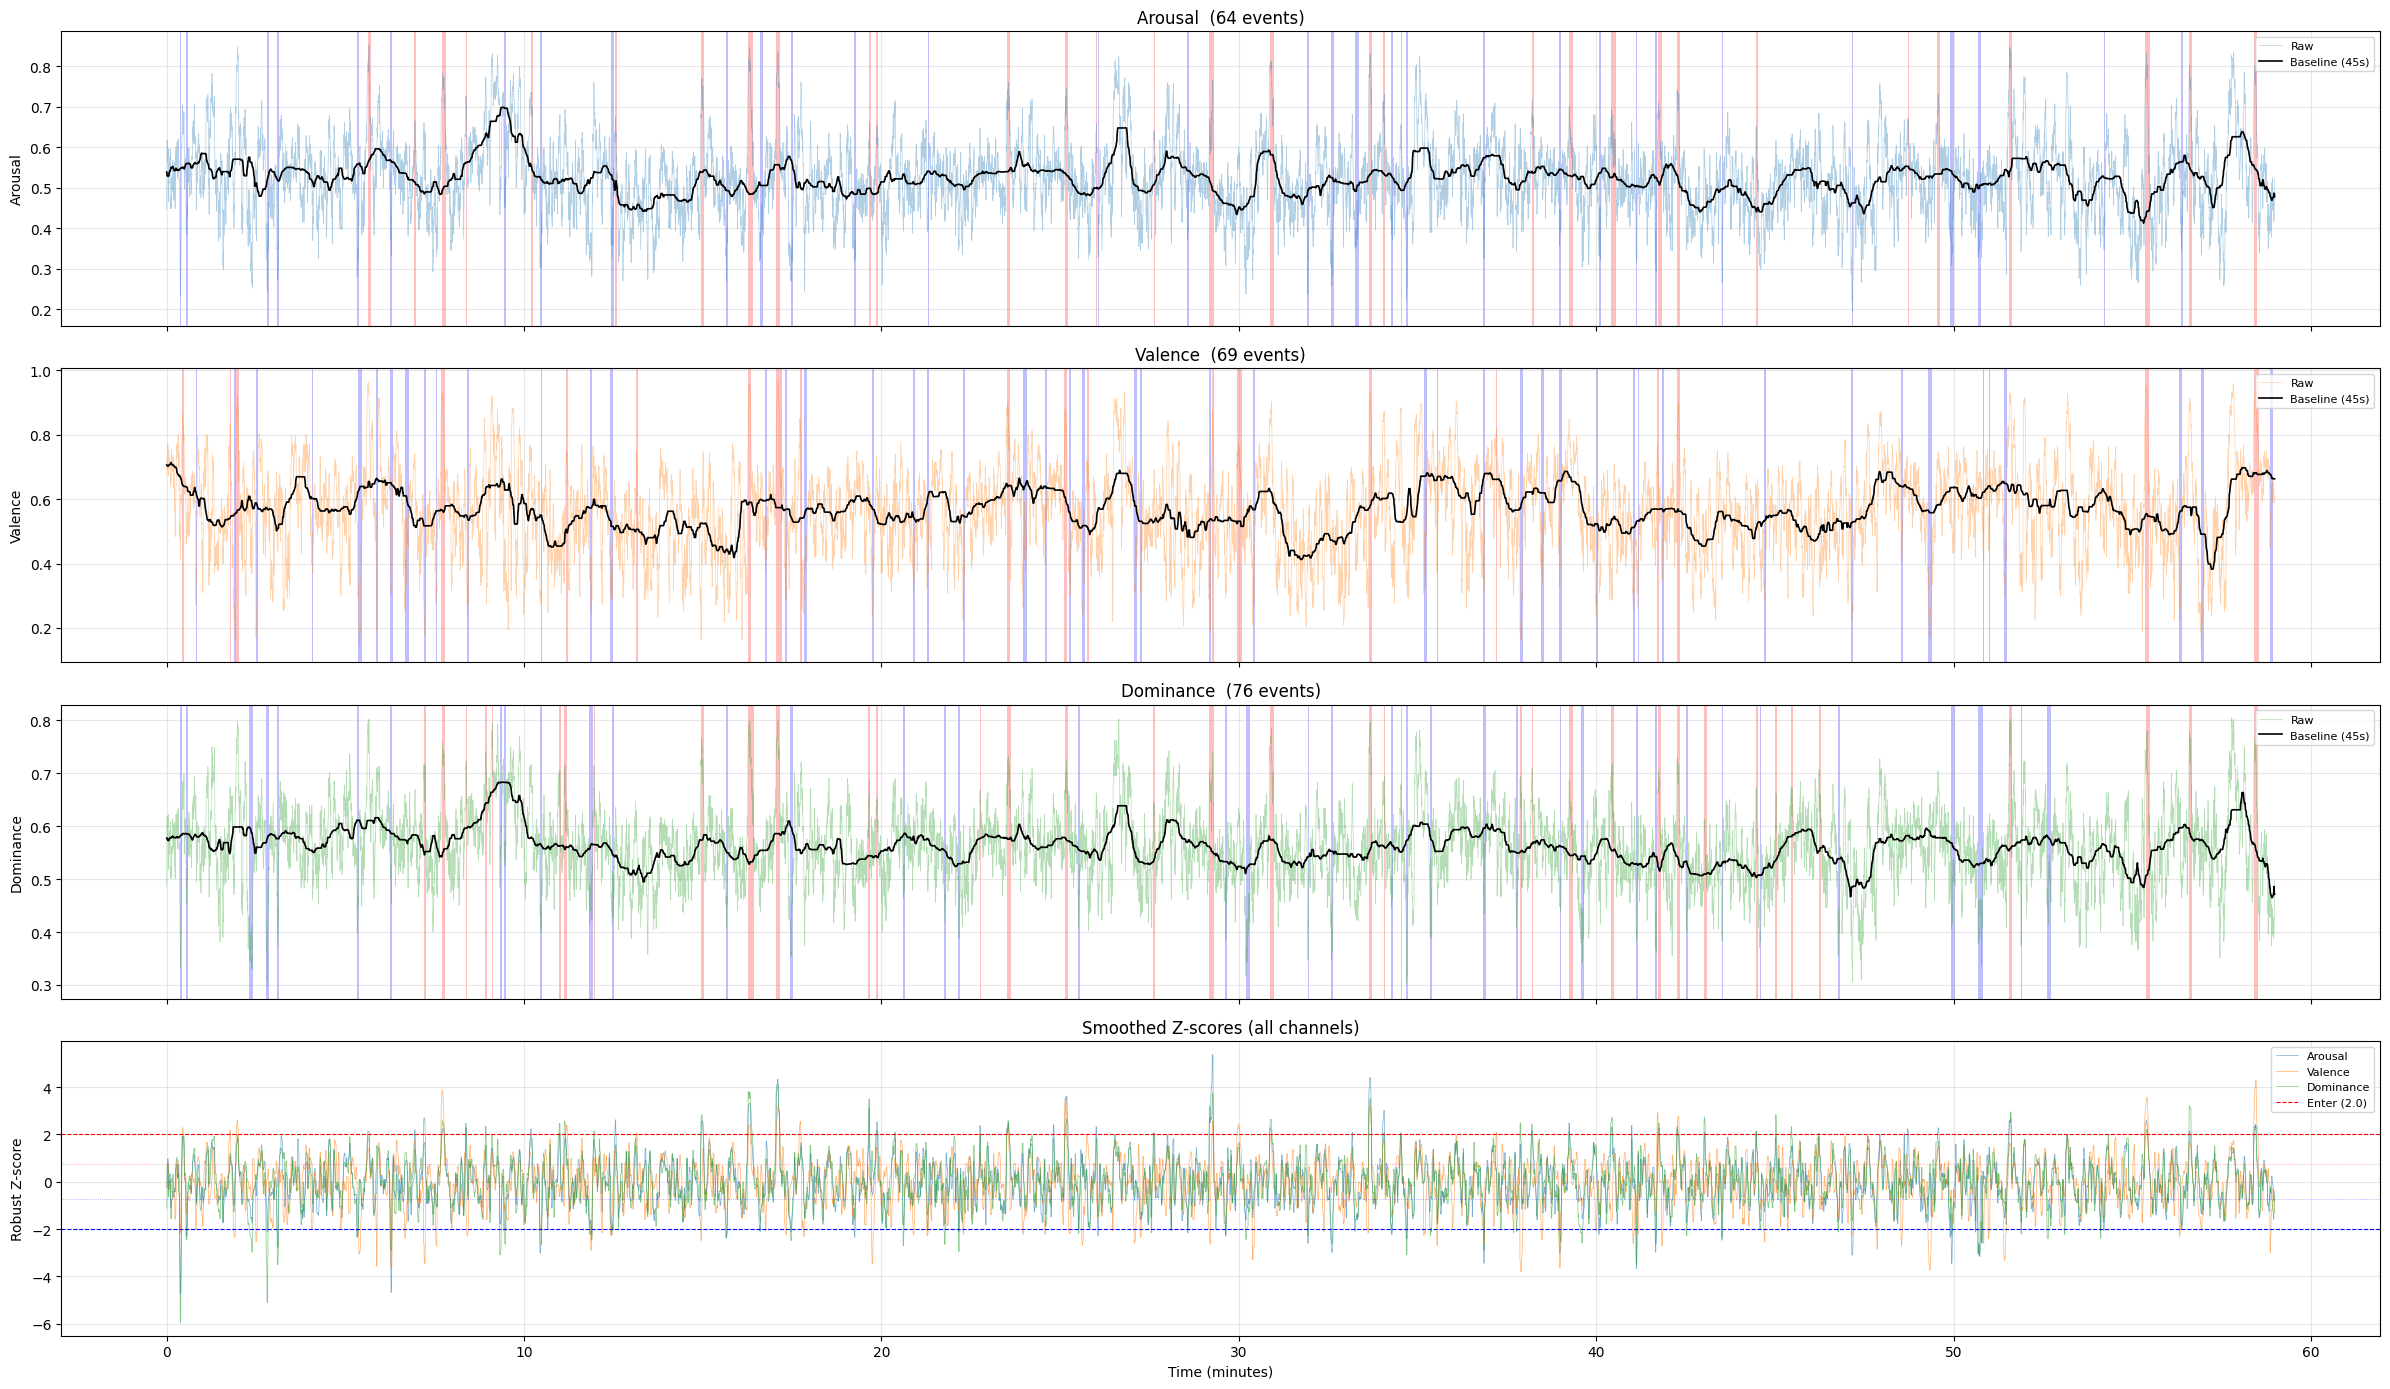

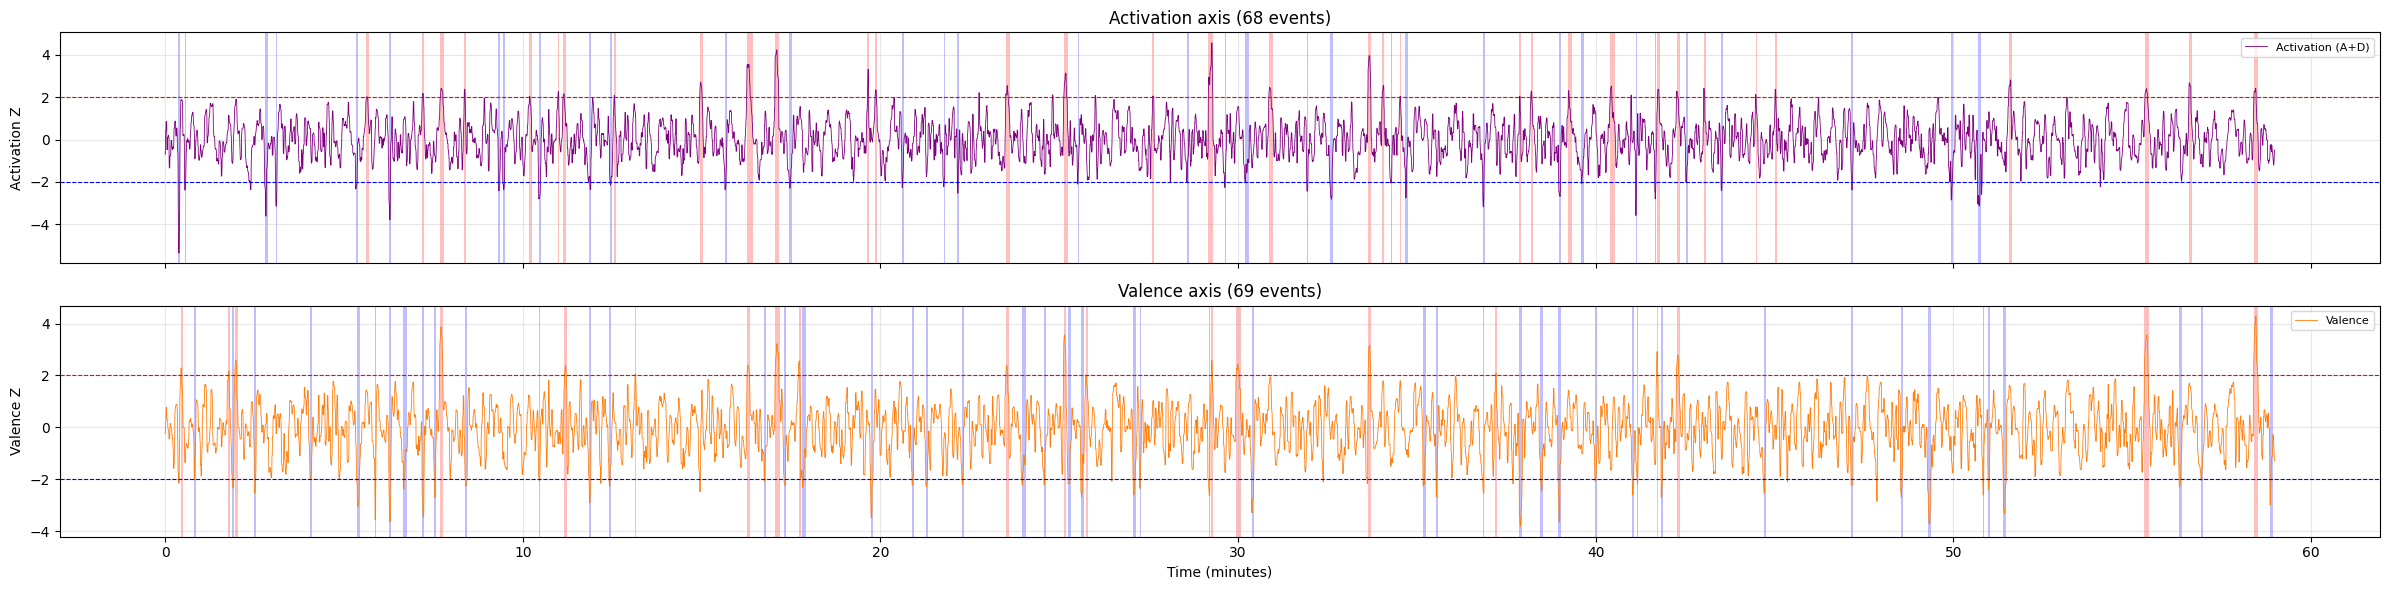

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

time_min = np.arange(len(arousal)) * HOP_SEC / 60.0

plot_signals = ["Arousal", "Valence", "Dominance"]
raw_signals = {"Arousal": arousal, "Valence": valence, "Dominance": dominance}
colors = {"Arousal": "tab:blue", "Valence": "tab:orange", "Dominance": "tab:green"}

fig, axs = plt.subplots(len(plot_signals) + 1, 1, figsize=(24, 14), sharex=True)

for i, name in enumerate(plot_signals):
    ax = axs[i]
    ax.plot(time_min, raw_signals[name], alpha=0.35, color=colors[name], linewidth=0.5, label="Raw")
    ax.plot(time_min, baselines[name].values, color="black", linewidth=1.2, label="Baseline (45s)")
    
    sig_events = events_df[events_df["signal"] == name]
    for _, ev in sig_events.iterrows():
        c = "red" if ev["direction"] == "positive" else "blue"
        ax.axvspan(ev["start_sec"] / 60, ev["end_sec"] / 60, alpha=0.25, color=c, linewidth=0)

    ax.set_ylabel(name)
    ax.set_title(f"{name}  ({len(sig_events)} events)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

# Z-score panel
ax_z = axs[-1]
for name in plot_signals:
    ax_z.plot(time_min, z_scores[name].values, alpha=0.6, linewidth=0.5, label=name)
ax_z.axhline(cfg["enter_threshold"], color="red", linestyle="--", linewidth=0.8, label=f"Enter ({cfg['enter_threshold']})")
ax_z.axhline(-cfg["enter_threshold"], color="blue", linestyle="--", linewidth=0.8)
ax_z.axhline(cfg["exit_threshold"], color="red", linestyle=":", linewidth=0.5, alpha=0.5)
ax_z.axhline(-cfg["exit_threshold"], color="blue", linestyle=":", linewidth=0.5, alpha=0.5)
ax_z.set_ylabel("Robust Z-score")
ax_z.set_title("Smoothed Z-scores (all channels)")
ax_z.legend(loc="upper right", fontsize=8)
ax_z.grid(True, alpha=0.3)
ax_z.set_xlabel("Time (minutes)")

plt.tight_layout()
plt.show()

# ── Activation + Valence 2D view ─────────────────────────────────────────────
act_events = events_df[events_df["signal"] == "Activation"]
val_events = events_df[events_df["signal"] == "Valence"]

fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 6), sharex=True)

ax1.plot(time_min, z_scores["Activation"].values, color="purple", linewidth=0.6, label="Activation (A+D)")
ax1.axhline(cfg["enter_threshold"], color="red", linestyle="--", linewidth=0.8)
ax1.axhline(-cfg["enter_threshold"], color="blue", linestyle="--", linewidth=0.8)
for _, ev in act_events.iterrows():
    c = "red" if ev["direction"] == "positive" else "blue"
    ax1.axvspan(ev["start_sec"] / 60, ev["end_sec"] / 60, alpha=0.25, color=c, linewidth=0)
ax1.set_ylabel("Activation Z")
ax1.set_title(f"Activation axis ({len(act_events)} events)")
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.plot(time_min, z_scores["Valence"].values, color="tab:orange", linewidth=0.6, label="Valence")
ax2.axhline(cfg["enter_threshold"], color="red", linestyle="--", linewidth=0.8)
ax2.axhline(-cfg["enter_threshold"], color="blue", linestyle="--", linewidth=0.8)
for _, ev in val_events.iterrows():
    c = "red" if ev["direction"] == "positive" else "blue"
    ax2.axvspan(ev["start_sec"] / 60, ev["end_sec"] / 60, alpha=0.25, color=c, linewidth=0)
ax2.set_ylabel("Valence Z")
ax2.set_title(f"Valence axis ({len(val_events)} events)")
ax2.legend(loc="upper right", fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel("Time (minutes)")

plt.tight_layout()
plt.show()

In [20]:
smoothing_win_duration = 5.25
smoothing_win_samples = int(smoothing_win_duration/HOP_SEC)
smoothing_poly_order = 3

In [21]:
y = arousal
x = window_centers_min

In [22]:
from scipy.signal import savgol_filter

y_smooth = savgol_filter(y, window_length=smoothing_win_samples, polyorder=smoothing_poly_order)


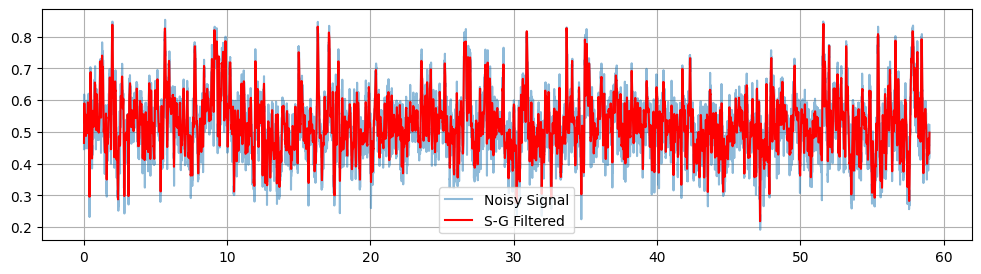

In [23]:

fig, ax = plt.subplots(figsize=(12,3))
# 3. Plot results
ax.plot(x, y, label='Noisy Signal', alpha=0.5)
ax.plot(x, y_smooth, label='S-G Filtered', color='red')
ax.legend()
ax.grid(True)
plt.show()

In [7]:
import sys
print(sys.executable)
print(sys.path)

/workspace/audio-classification-playground/.venv/bin/python3
['/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/workspace/audio-classification-playground/.venv/lib/python3.10/site-packages', '/workspace/audio-classification-playground']


In [2]:
import sys, subprocess
result = subprocess.run(
    [sys.executable, "-m", "pip", "show", "audio-classification-playground"],
    capture_output=True, text=True
)
print(result.stdout)

In [3]:
import sys
for p in sys.path:
    print(p)

/usr/lib/python310.zip
/usr/lib/python3.10
/usr/lib/python3.10/lib-dynload

/workspace/audio-classification-playground/.venv/lib/python3.10/site-packages
/workspace/audio-classification-playground
